# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *
from data_operations_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran


from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import r2_score

In [2]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')
connection_link_var = repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite'

# Data

In [3]:
gdf = import_spatial_point_data_frame(
                connection_link_lnx = repo_path_unix+"/03_simulated_data/simulated_data.sqlite",
                layer_name ='gdf_rho_0_75',
                crs_param = 3857
                                        )
df = import_non_spatial_data_frame(
                connection_link = connection_link_var,
                df_to_return_name =  'gdf_rho_0_75_sp'
                                        )

In [4]:
df

,unit_id,t,propensity,t_tot,t_tot_cat,t_tot_cat_underestim,t_tot_cat_overerestim,odr_1,odr_2,odr_3,...,y_ns,spatial_predictor_100_1,spatial_predictor_100_3,spatial_predictor_100_4,spatial_predictor_100_2,spatial_predictor_100_6,spatial_predictor_100_5,spatial_predictor_100_9,spatial_predictor_500_9,spatial_predictor_100_10
0,1000,0,4.254438,0,control,control,control,0,0,0,...,3.583302,-0.012927,0.010595,0.025685,-0.004391,0.017704,-0.015820,-0.022337,0.020665,-0.039483
1,1001,0,2.048454,0,control,control,control,0,0,0,...,1.664774,-0.018153,0.015350,0.036128,-0.006397,0.025482,-0.023075,-0.033027,0.024074,-0.053469
2,1002,0,1.078793,0,control,control,control,0,0,0,...,0.924681,-0.021105,0.018410,0.041466,-0.007911,0.030127,-0.027608,-0.039891,0.027345,-0.056255
3,1003,0,-2.519299,0,control,control,control,0,0,0,...,-1.424234,-0.022892,0.020462,0.043284,-0.009118,0.032335,-0.030302,-0.043785,0.030559,-0.049756
4,1004,0,1.401347,0,control,control,control,0,0,0,...,0.939380,-0.024033,0.021902,0.042545,-0.010160,0.032619,-0.031721,-0.045301,0.033249,-0.036231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,1795,0,0.546255,0,control,control,control,0,0,0,...,0.515627,0.090029,0.034072,0.015740,-0.083012,0.008130,0.041915,0.003435,0.047070,-0.002933
796,1796,0,0.217175,0,control,control,control,0,0,0,...,-0.243606,0.102460,0.033038,0.026323,-0.115110,-0.009900,0.063532,-0.000478,0.057962,-0.001135
797,1797,0,-0.753369,0,control,control,control,0,0,0,...,-0.990687,0.119752,0.033995,0.038097,-0.152442,-0.028509,0.089029,-0.003795,0.067823,0.000879
798,1798,0,1.541784,0,control,control,control,0,0,0,...,0.898532,0.144678,0.037568,0.050946,-0.196466,-0.046410,0.117683,-0.006542,0.077051,0.002785


In [4]:
gdf_pre =gdf.copy()
gdf = gdf_pre.drop(columns = [c for c in gdf_pre.columns.tolist() if 'spatial_predictor' in c]).copy()
# df = import_non_spatial_data_frame(
#                 connection_link = connection_link_var,
#                 df_to_return_name =  'gdf_rho_0_75_sp_t_dr5'
#                                         )

df2 = df[['unit_id']+[c for c in df.columns.tolist() if 'spatial_predictor' in c]].copy()
gdf2 = gdf.merge(df2, on = ['unit_id'])

# Modelling causal inference

## Single df

### Data preparation

In [ ]:
X_ns = gdf2[["c1","c2",
         ]].values
X = gdf2[["c1","c2",
         'spatial_predictor_100_1',
    'spatial_predictor_100_3',
    'spatial_predictor_100_4',
    'spatial_predictor_100_2',
    'spatial_predictor_100_6',
    'spatial_predictor_100_5',
    'spatial_predictor_100_9',
    'spatial_predictor_500_9',
    'spatial_predictor_100_10'
         ]].values
y = gdf2["y_dep_var"].values.reshape(-1,1)
T = gdf2["t"].values


T_tot = gdf2["t_tot"].values
Xdf = gdf2[['t','odr_1','odr_2','odr_3',
            #'odr_4', 
            "c1","c2",
         'spatial_predictor_100_1',
    'spatial_predictor_100_3',
    'spatial_predictor_100_4',
    'spatial_predictor_100_2',
    'spatial_predictor_100_6',
    'spatial_predictor_100_5',
    'spatial_predictor_100_9',
    'spatial_predictor_500_9',
    'spatial_predictor_100_10'
         ]]
Xdf2 = gdf2[['t','odr_1','odr_2','odr_3',
             #'odr_4', 
             "c1","c2",
         #"C3","Cs"
         ]]


Xdf3 = gdf2[['t',
            #'odr_4', 
            "c1","c2",
         'spatial_predictor_100_1',
    'spatial_predictor_100_3',
    'spatial_predictor_100_4',
    'spatial_predictor_100_2',
    'spatial_predictor_100_6',
    'spatial_predictor_100_5',
    'spatial_predictor_100_9',
    'spatial_predictor_500_9',
    'spatial_predictor_100_10'
         ]]

Xdf4 = gdf2[['t',
            #'odr_4', 
            "c1","c2",
         ]]

X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
X_l3 = sm.add_constant(Xdf3)
X_l4 = sm.add_constant(Xdf4)
y_l = gdf2["y_dep_var"]
Y = gdf2['y_dep_var'].values

gdf3 = gdf2.copy()

gdf3["t_catS"] = gdf3['t']
gdf3["t_catS"] = gdf3["t_catS"].replace({
    0: "control",
    1: "inner_ring"
})

T_S= gdf3['t_catS'].values

gdf3['t_tot_cat3'] = gdf3['t_tot_cat']
gdf3.loc[gdf3['t_tot_cat']=='treated_outer_ring4', 't_tot_cat3'] = 'control'

T_M= gdf3['t_tot_cat3'].values
T_M= T_M.astype(str)

gdf4 = gdf2.copy()[['unit_id',
            't',
            'propensity',
            't_tot', 't_tot_cat']]
gdf4.loc[(gdf4['t_tot'] == 1)&(gdf4['t'] != 1), 't_double']= 1
gdf4['t_double_cat'] = gdf4['t_tot_cat'].replace({ 
    'treated_outer_ring4':'control',
     'treated_outer_ring3':'treated_outer_ring',                                             
      'treated_outer_ring2':'treated_outer_ring',
      'treated_outer_ring1':'treated_outer_ring',                                            
                                                  })
gdf4 = gdf4.fillna(0)



T_Dbl= gdf4['t_double_cat'].values
T_Dbl= T_Dbl.astype(str)

gdf3 = gdf3.rename(columns = {'t': 'treated_inner_ring',
                              'odr_1':'treated_outer_ring1', 
                              'odr_2':'treated_outer_ring2', 
                              'odr_3':'treated_outer_ring3', 
                              'odr_4':'treated_outer_ring4'
                              })
T_mult = gdf3[[ 
         'treated_inner_ring', 'treated_outer_ring1','treated_outer_ring2','treated_outer_ring3',
         #'treated_outer_ring4'
         ]].to_numpy()

gdf5 = gdf4.copy()


gdf5 = gdf5.rename(columns = {'t': 'treated_inner_ring',
                              't_double':'treated_outer_rings', 
                              })

T_DT = gdf5[[ 
         'treated_inner_ring', 'treated_outer_rings'
         ]].to_numpy()



T_DT_id = gdf2[[ 
         't', 'cont_t_n'
         ]].to_numpy()

gdf2_22 = gdf.copy()
gdf2_22["x"] = gdf2_22.geometry.x.astype(int)
gdf2_22["y"] = gdf2_22.geometry.y.astype(int)

n = len(gdf2_22)

coords = np.array(
        list(zip(gdf2_22["x"], gdf2_22["y"]))
    )


W_mat = DistanceBand(
        coords,
        threshold=100 + 1,
        binary=True,
        silence_warnings=True
    ) 

In [6]:
replacing_dict_0_ring = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                            #4:'treated_outer_ring4'
                                             }

replacing_dict_odr_ring = {'t':'treated_inner_ring', 
                                                                        'odr_1':'treated_outer_ring1', 
                                                                        'odr_2':'treated_outer_ring2',
                                                                        'odr_3':'treated_outer_ring3',
                                                                          #'odr_4':'treated_outer_ring4'
                                                                          }

### Multi treatment

#### With spatial regressors

##### S learner

In [7]:
RF_s_learner = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_multT, lb_slearn_multT, ub_slearn_multT = RF_s_learner.estimate_ate(X, T_M, Y, return_ci = True)
ite_slearn_multT = RF_s_learner.fit_predict(X, T_M, Y)
ITE_df_slearn_multT = pd.DataFrame(ite_slearn_multT).rename(columns = replacing_dict_0_ring)
ITE_df_slearn_multT['treated'] = T_M
ITE_df_slearn_multT['ITE_real'] = gdf2['tau']
ITE_df_slearn_multT['Y'] = Y
ITE_df_slearn_multT

,treated_inner_ring,treated_outer_ring1,treated_outer_ring2,treated_outer_ring3,treated,ITE_real,Y
0,1.725185,0.679967,0.119662,-0.026845,control,0.0,0.599436
1,1.489025,0.261284,0.016139,0.010158,control,0.0,1.897156
2,1.352634,0.637832,0.016258,-0.013648,control,0.0,0.782082
3,1.266732,0.419010,0.139116,0.022837,control,0.0,0.078709
4,1.826286,0.457809,0.119843,-0.027616,control,0.0,0.398665
...,...,...,...,...,...,...,...
795,1.640543,0.378795,0.153931,0.016775,control,0.0,0.606883
796,1.244035,0.441308,0.167440,0.017416,control,0.0,0.227247
797,1.929871,0.231842,-0.003375,0.058787,control,0.0,-1.419136
798,1.460143,0.689721,0.043091,-0.031225,control,0.0,0.703590


In [8]:
df_effectbase = pd.DataFrame({
                'ring':['treated_inner_ring', 'treated_outer_ring1', 'treated_outer_ring2','treated_outer_ring3',
                        #'treated_outer_ring4'
                        ],
              'true_effect':[gdf2[gdf2['t'] == 1]['tau'].mean(), gdf2[gdf2['odr_1'] == 1]['tau'].mean(), 
                             gdf2[gdf2['odr_2'] == 1]['tau'].mean(), gdf2[gdf2['odr_3'] == 1]['tau'].mean(), 
                               #gdf2[gdf2['odr_4'] == 1]['tau'].mean()
                               ],
              })
df_multi_treatment_effects_Slearn = make_treatment_effects_df(ITE_df_slearn_multT,  [ 'treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mSlearn_sp', treated_col='treated')
df_multi_effect_pre1 = df_effectbase.merge(df_multi_treatment_effects_Slearn, on = 'ring', how= 'left')
df_multi_effect_pre1

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp
0,treated_inner_ring,1.500000,1.908071,0.068150
1,treated_outer_ring1,0.969857,0.451474,0.056892
2,treated_outer_ring2,0.514273,0.192381,0.028083
3,treated_outer_ring3,0.112335,0.017216,0.006585


##### Linear DML

In [9]:
est_LDML = LinearDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                       max_depth=3,
                                                                       min_samples_leaf=20)),
                featurizer=PolynomialFeatures(degree=2, include_bias=False),
                cv=None)

est_LDML.fit(Y, T_mult, X=X, 
        #W=W
        )
te_pred_LDML = est_LDML.const_marginal_effect(X)

ITE_LDML= pd.DataFrame(te_pred_LDML).rename(columns = replacing_dict_0_ring)
ITE_LDML['treated'] = T_M
df_multi_treatment_effects_LDML = make_treatment_effects_df(ITE_LDML,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mLDML_sp', treated_col='treated')
df_multi_effect_pre2 = df_multi_effect_pre1.merge(df_multi_treatment_effects_LDML, on = 'ring', how= 'left')
df_multi_effect_pre2 

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp
0,treated_inner_ring,1.500000,1.908071,0.068150,-5.585373,1.225789
1,treated_outer_ring1,0.969857,0.451474,0.056892,0.863011,0.482048
2,treated_outer_ring2,0.514273,0.192381,0.028083,0.128655,0.274763
3,treated_outer_ring3,0.112335,0.017216,0.006585,0.285293,0.170875


##### Causal forest

In [10]:
est2 = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2.tune(Y, T_mult, X=X, 
          #W=W
          )
est2.fit(Y, T_mult, X=X, 
         #W=W
         )

te_pred2 = est2.const_marginal_effect(X)
ITE_CF=pd.DataFrame(te_pred2).rename(columns = replacing_dict_0_ring)
ITE_CF['treated'] = T_M
df_multi_treatment_effects_CF = make_treatment_effects_df(ITE_CF,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mCF_sp', treated_col='treated')
df_multi_effect_pre3 = df_multi_effect_pre2.merge(df_multi_treatment_effects_CF, on = 'ring', how= 'left')
df_multi_effect_pre3 

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp
0,treated_inner_ring,1.500000,1.908071,0.068150,-5.585373,1.225789,0.940800,0.035423
1,treated_outer_ring1,0.969857,0.451474,0.056892,0.863011,0.482048,0.605244,0.091710
2,treated_outer_ring2,0.514273,0.192381,0.028083,0.128655,0.274763,0.316000,0.035011
3,treated_outer_ring3,0.112335,0.017216,0.006585,0.285293,0.170875,-0.011101,0.040567


##### Cross sectional DiD with spatial predictors

In [11]:
model_cs_did_sp_pred = sm.OLS(y_l, X_l)
results_cs_did_sp_pred = model_cs_did_sp_pred.fit()

coef_df_cs_did_sp_pred = pd.DataFrame({
    "ring": results_cs_did_sp_pred.params.index,
    "att_mDiD_sp_pred": results_cs_did_sp_pred.params.values,
    "se_mDiD_sp_pred": results_cs_did_sp_pred.bse.values
})
coef_df_cs_did_sp_pred = coef_df_cs_did_sp_pred[coef_df_cs_did_sp_pred['ring'].isin(['t', 
                                                            'odr_1', 'odr_2',
                                                            'odr_3',
                                                             # 'odr_4'
                                                            ])].copy()

coef_df_cs_did_sp_pred['ring'] = coef_df_cs_did_sp_pred['ring'].replace(replacing_dict_odr_ring)
df_multi_effect_pre4 = df_multi_effect_pre3.merge(coef_df_cs_did_sp_pred, on = 'ring', how= 'left')
df_multi_effect_pre4

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp,att_mDiD_sp_pred,se_mDiD_sp_pred
0,treated_inner_ring,1.500000,1.908071,0.068150,-5.585373,1.225789,0.940800,0.035423,1.674243,0.135575
1,treated_outer_ring1,0.969857,0.451474,0.056892,0.863011,0.482048,0.605244,0.091710,1.035972,0.164450
2,treated_outer_ring2,0.514273,0.192381,0.028083,0.128655,0.274763,0.316000,0.035011,0.732028,0.154816
3,treated_outer_ring3,0.112335,0.017216,0.006585,0.285293,0.170875,-0.011101,0.040567,0.276088,0.141709


##### SDM DiD

In [12]:
did_sdm_ysp = ML_Lag(
    y,
    X_l2,
    w=W_mat,              
    slx_lags=0,       
    name_y="y",
    # name_x=['t','odr_1','odr_2','odr_3','odr_4', "c1","c2"
    #         ]
)

did_sdm_ysp_coefs = did_sdm_ysp.betas.flatten()
did_sdm_ysp_ses = np.sqrt(np.diag(did_sdm_ysp.vm))
did_sdm_ysp_variables = did_sdm_ysp.name_x.copy()

coef_did_sdm_ysp = pd.DataFrame({
    "ring": did_sdm_ysp_variables,
    "att_sdm": did_sdm_ysp_coefs,
    "att_sdm_se": did_sdm_ysp_ses 
})
coef_did_sdm_ysp = coef_did_sdm_ysp[coef_did_sdm_ysp['ring'].isin(['t', 'odr_1', 'odr_2', 'odr_3'])]
coef_did_sdm_ysp['ring'] = coef_did_sdm_ysp['ring'].replace(replacing_dict_odr_ring)
df_multi_effect_sp_regr = df_multi_effect_pre4.merge(coef_did_sdm_ysp, on = 'ring', how= 'left')
df_multi_effect_sp_regr

ML_Lag


,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp,att_mDiD_sp_pred,se_mDiD_sp_pred,att_sdm,att_sdm_se
0,treated_inner_ring,1.500000,1.908071,0.068150,-5.585373,1.225789,0.940800,0.035423,1.674243,0.135575,1.503500,0.125056
1,treated_outer_ring1,0.969857,0.451474,0.056892,0.863011,0.482048,0.605244,0.091710,1.035972,0.164450,0.880100,0.153727
2,treated_outer_ring2,0.514273,0.192381,0.028083,0.128655,0.274763,0.316000,0.035011,0.732028,0.154816,0.605032,0.141760
3,treated_outer_ring3,0.112335,0.017216,0.006585,0.285293,0.170875,-0.011101,0.040567,0.276088,0.141709,0.174761,0.129987


##### Results visualization

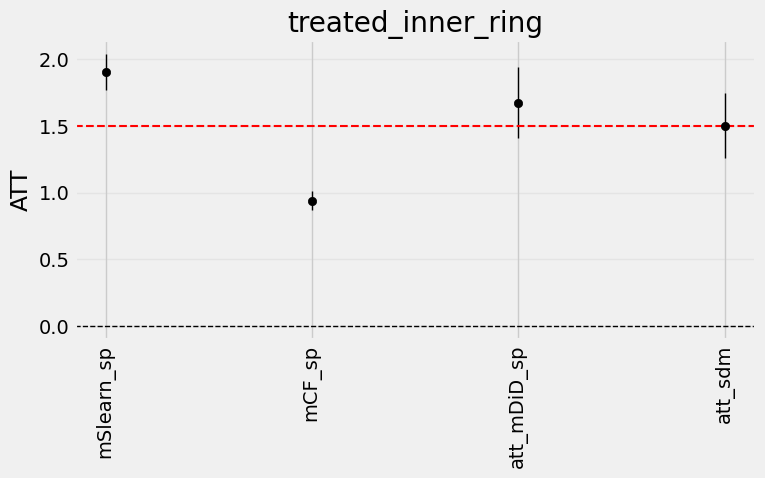

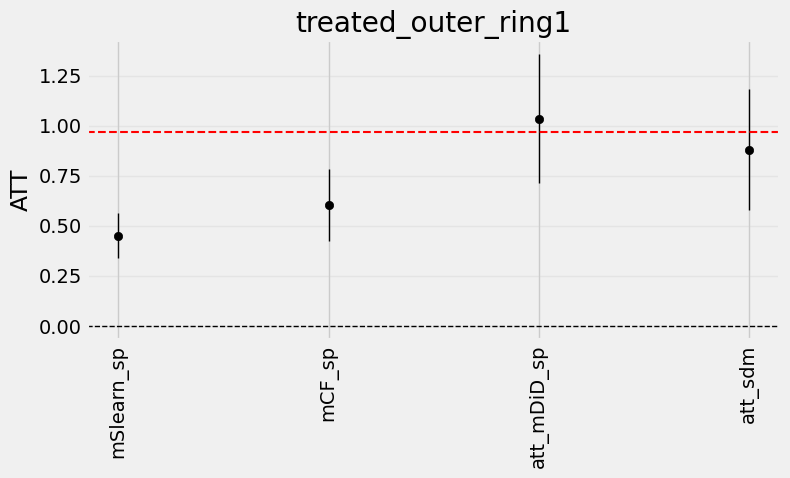

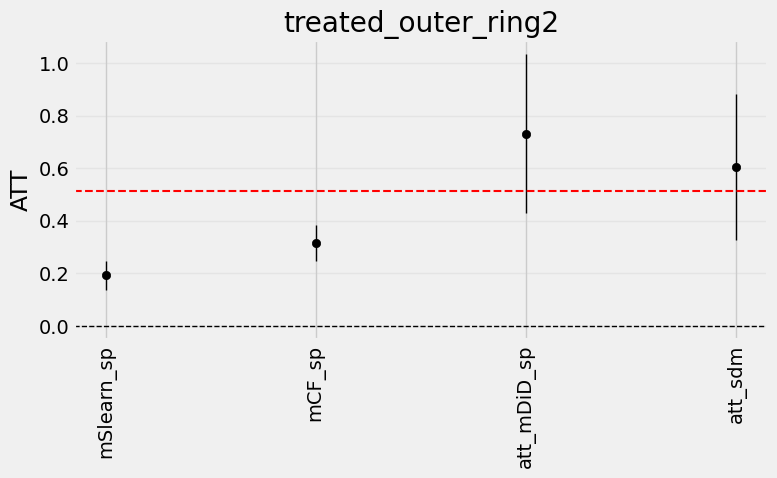

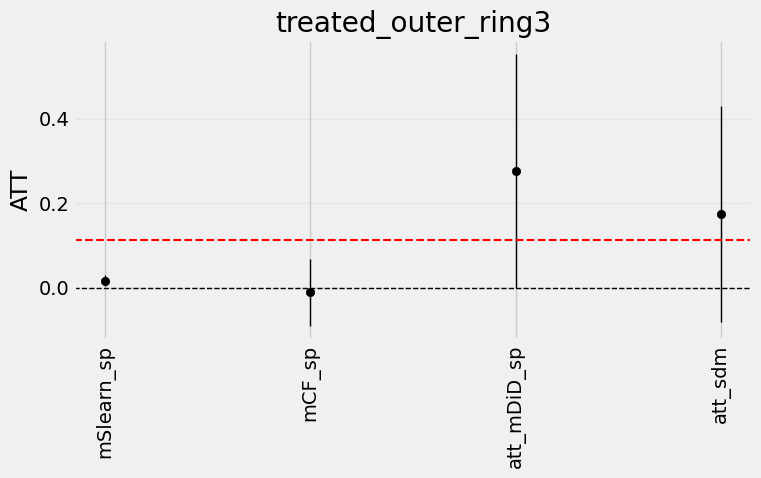

In [13]:
att_models_sp = {
    "mSlearn_sp": ("att_mSlearn_sp", "se_mSlearn_sp"),
    #"mLDML_sp": ("att_mLDML_sp", "se_mLDML_sp"),
    "mCF_sp": ("att_mCF_sp", "se_mCF_sp"),
    "att_mDiD_sp": ("att_mDiD_sp_pred", "se_mDiD_sp_pred"),
    "att_sdm": ("att_sdm", "att_sdm_se"),
    # "mSlearn_nsp": ("att_mSlearn_nsp", "se_mSlearn_nsp"),
    # #"mLDML_nsp": ("att_mLDML_nsp", "se_mLDML_nsp"),
    # "mCF_nsp": ("att_mCF_nsp", "se_mCF_nsp"),
    # "att_mDiD": ("att_mDiD", "se_mDiD")
}
for ring in df_multi_effect_sp_regr['ring'].unique().tolist():
    plot_att_row(
        df=df_multi_effect_sp_regr,
        ring_name=ring,
        true_effect_col="true_effect",
        att_dict=att_models_sp
    )

#### Without spatial regressors

##### S learner

In [14]:
RF_s_learner_nsp = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_multT_nsp, lb_slearn_multT_nsp, ub_slearn_multT_nsp = RF_s_learner.estimate_ate(X_ns, T_M, Y, return_ci = True)
ite_slearn_multT_nsp = RF_s_learner_nsp.fit_predict(X_ns, T_M, Y)
ITE_df_slearn_multT_nsp = pd.DataFrame(ite_slearn_multT_nsp).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                             #4:'treated_outer_ring4'
                                             })
ITE_df_slearn_multT_nsp['treated'] = T_M
df_multi_treatment_effects_Slearn_nsp = make_treatment_effects_df(ITE_df_slearn_multT_nsp,  [ 'treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mSlearn_nsp', treated_col='treated')
df_multi_effect_nspreg_pre1 = df_effectbase.merge(df_multi_treatment_effects_Slearn_nsp, on = 'ring', how= 'left')
df_multi_effect_nspreg_pre1

,ring,true_effect,att_mSlearn_nsp,se_mSlearn_nsp
0,treated_inner_ring,1.500000,1.760954,0.067659
1,treated_outer_ring1,0.969857,0.775703,0.095291
2,treated_outer_ring2,0.514273,0.357487,0.056836
3,treated_outer_ring3,0.112335,0.070012,0.032917


##### Linear DML

In [15]:
est_LDML_nsp = LinearDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                       max_depth=3,
                                                                       min_samples_leaf=20)),
                featurizer=PolynomialFeatures(degree=2, include_bias=False),
                cv=None)

est_LDML_nsp.fit(Y, T_mult, X=X_ns, 
        #W=W
        )
te_pred_LDML_nsp = est_LDML_nsp.const_marginal_effect(X_ns)

ITE_LDML_nsp= pd.DataFrame(te_pred_LDML_nsp).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                             #4:'treated_outer_ring4'
                                             })
ITE_LDML_nsp['treated'] = T_M
df_multi_treatment_effects_LDML_nsp = make_treatment_effects_df(ITE_LDML_nsp,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mLDML_nsp', treated_col='treated')
df_multi_effect_nspreg_pre2 = df_multi_effect_nspreg_pre1.merge(df_multi_treatment_effects_LDML_nsp, on = 'ring', how= 'left')
df_multi_effect_nspreg_pre2 

,ring,true_effect,att_mSlearn_nsp,se_mSlearn_nsp,att_mLDML_nsp,se_mLDML_nsp
0,treated_inner_ring,1.500000,1.760954,0.067659,1.758869,0.029954
1,treated_outer_ring1,0.969857,0.775703,0.095291,1.028699,0.037072
2,treated_outer_ring2,0.514273,0.357487,0.056836,0.671685,0.054291
3,treated_outer_ring3,0.112335,0.070012,0.032917,0.146894,0.045713


##### Causal forest

In [16]:
est2_cf_nsp = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2_cf_nsp.tune(Y, T_mult, X=X_ns, 
          #W=W
          )
est2_cf_nsp.fit(Y, T_mult, X=X_ns, 
         #W=W
         )

te_pred2_nsp = est2_cf_nsp.const_marginal_effect(X_ns)
ITE_CF_nsp=pd.DataFrame(te_pred2_nsp).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                             #4:'treated_outer_ring4'
                                             })
ITE_CF_nsp['treated'] = T_M
df_multi_treatment_effects_CF_nsp = make_treatment_effects_df(ITE_CF_nsp,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mCF_nsp', treated_col='treated')
df_multi_effect_nspreg_pre3 = df_multi_effect_nspreg_pre2.merge(df_multi_treatment_effects_CF_nsp, on = 'ring', how= 'left')
df_multi_effect_nspreg_pre3

,ring,true_effect,att_mSlearn_nsp,se_mSlearn_nsp,att_mLDML_nsp,se_mLDML_nsp,att_mCF_nsp,se_mCF_nsp
0,treated_inner_ring,1.500000,1.760954,0.067659,1.758869,0.029954,1.745263,0.012552
1,treated_outer_ring1,0.969857,0.775703,0.095291,1.028699,0.037072,1.023931,0.019792
2,treated_outer_ring2,0.514273,0.357487,0.056836,0.671685,0.054291,0.646903,0.014804
3,treated_outer_ring3,0.112335,0.070012,0.032917,0.146894,0.045713,0.164683,0.016769


##### DiD without spatial predictors

In [17]:
model_cs_did = sm.OLS(y_l, X_l2)
results_cs_did = model_cs_did.fit()

coef_df_cs_did = pd.DataFrame({
    "ring": results_cs_did.params.index,
    "att_mDiD": results_cs_did.params.values,
    "se_mDiD": results_cs_did.bse.values
})
coef_df_cs_did = coef_df_cs_did[coef_df_cs_did['ring'].isin(['t', 
                                                            'odr_1', 'odr_2',
                                                            'odr_3',
                                                             # 'odr_4'
                                                            ])].copy()

coef_df_cs_did['ring'] = coef_df_cs_did['ring'].replace(replacing_dict_odr_ring)
df_multi_effect_nspreg = df_multi_effect_nspreg_pre3.merge(coef_df_cs_did, on = 'ring', how= 'left')
df_multi_effect_nspreg

,ring,true_effect,att_mSlearn_nsp,se_mSlearn_nsp,att_mLDML_nsp,se_mLDML_nsp,att_mCF_nsp,se_mCF_nsp,att_mDiD,se_mDiD
0,treated_inner_ring,1.500000,1.760954,0.067659,1.758869,0.029954,1.745263,0.012552,1.510667,0.098563
1,treated_outer_ring1,0.969857,0.775703,0.095291,1.028699,0.037072,1.023931,0.019792,0.897618,0.145049
2,treated_outer_ring2,0.514273,0.357487,0.056836,0.671685,0.054291,0.646903,0.014804,0.614010,0.138976
3,treated_outer_ring3,0.112335,0.070012,0.032917,0.146894,0.045713,0.164683,0.016769,0.180923,0.129594


#### Results visualization

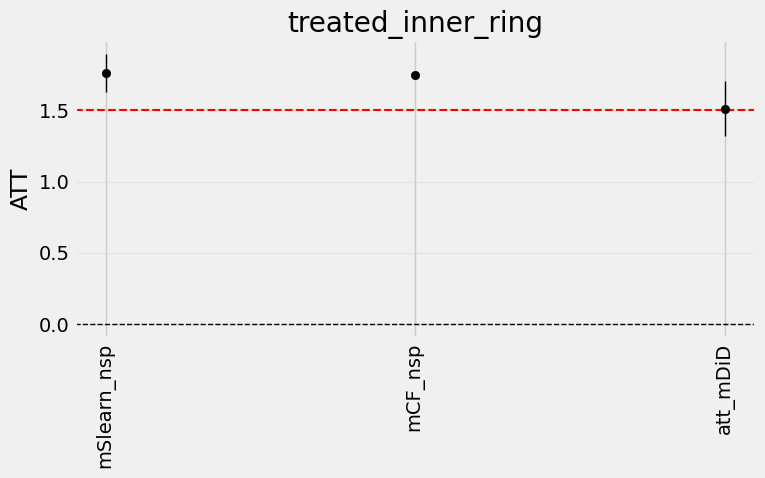

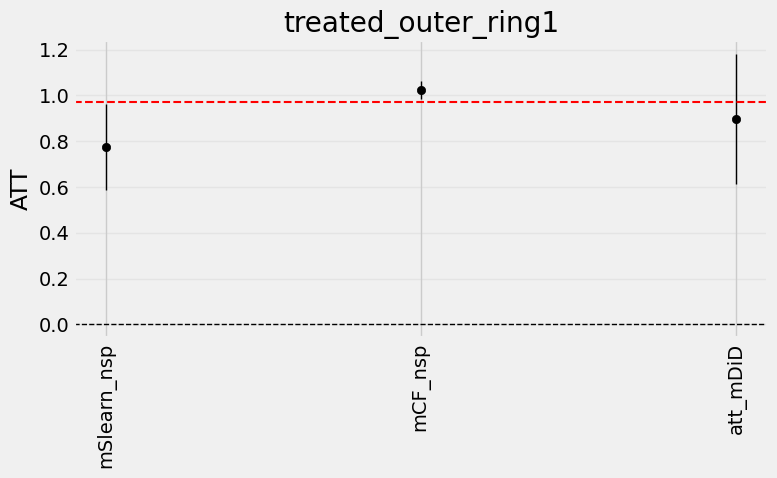

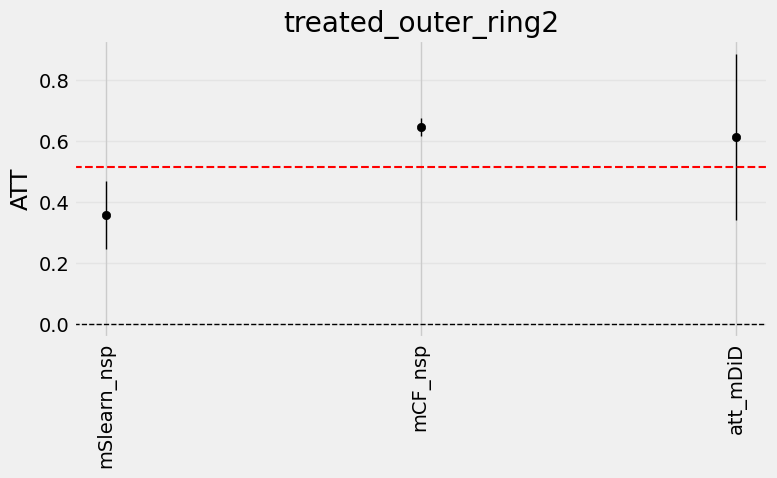

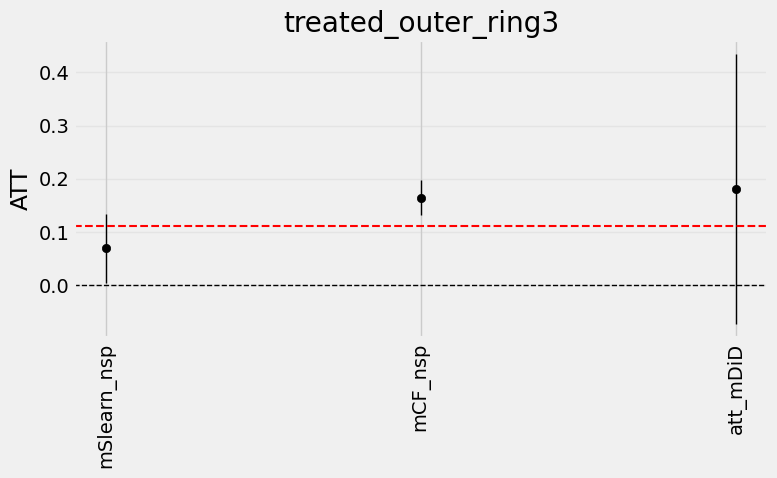

In [18]:
att_models_nspreg = {
    "mSlearn_nsp": ("att_mSlearn_nsp", "se_mSlearn_nsp"),
    #"mLDML_nsp": ("att_mLDML_nsp", "se_mLDML_nsp"),
    "mCF_nsp": ("att_mCF_nsp", "se_mCF_nsp"),
    "att_mDiD": ("att_mDiD", "se_mDiD")
}
for ring in df_multi_effect_nspreg['ring'].unique().tolist():
    plot_att_row(
        df=df_multi_effect_nspreg,
        ring_name=ring,
        true_effect_col="true_effect",
        att_dict=att_models_nspreg
    )

### Single treatment

#### With spatial regressors

##### S learner

In [19]:
RF_s_learnerS = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_Sngl, lb_slearn_Sngl, ub_slearn_Sngl = RF_s_learnerS.estimate_ate(X, T_S, Y, return_ci = True)
ite_slearn_Sngl = RF_s_learnerS.fit_predict(X, T_S, Y)
ITE_df_slearn_Sngl = pd.DataFrame(ite_slearn_Sngl).rename(columns = replacing_dict_0_ring)
ITE_df_slearn_Sngl['treated'] = T_M
ITE_df_slearn_Sngl['ITE_real'] = gdf2['tau']
ITE_df_slearn_Sngl['Y'] = Y
ITE_df_slearn_Sngl

,treated_inner_ring,treated,ITE_real,Y
0,1.879146,control,0.0,0.599436
1,1.337183,control,0.0,1.897156
2,1.492091,control,0.0,0.782082
3,1.150047,control,0.0,0.078709
4,1.885308,control,0.0,0.398665
...,...,...,...,...
795,1.513587,control,0.0,0.606883
796,1.048995,control,0.0,0.227247
797,1.390904,control,0.0,-1.419136
798,1.369226,control,0.0,0.703590


In [20]:
df_single_treatment_effects_SlearnS = make_treatment_effects_df(ITE_df_slearn_Sngl,  [ 'treated_inner_ring',
             ],'sSlearn_sp', treated_col='treated')
df_single_effect_pre1 = df_effectbase[df_effectbase['ring'] == 'treated_inner_ring'].merge(df_single_treatment_effects_SlearnS, on = 'ring', how= 'left')
df_single_effect_pre1

,ring,true_effect,att_sSlearn_sp,se_sSlearn_sp
0,treated_inner_ring,1.5,1.192888,0.057947


In [21]:
ITE_df_slearn_Sngl['treated'].unique()

array(['control', 'treated_outer_ring3', 'treated_outer_ring2',
       'treated_outer_ring1', 'treated_inner_ring'], dtype=object)

In [22]:
ITE_df_slearn_Sngl[ITE_df_slearn_Sngl['treated'] == 'treated_outer_ring1']

,treated_inner_ring,treated,ITE_real,Y
187,0.860795,treated_outer_ring1,0.288834,-0.326497
188,0.363137,treated_outer_ring1,0.828616,0.137409
189,1.792507,treated_outer_ring1,0.959820,-0.307235
190,1.310035,treated_outer_ring1,1.006717,-1.165214
191,1.331097,treated_outer_ring1,0.717765,-0.616354
192,0.592154,treated_outer_ring1,0.760858,0.789103
193,0.196951,treated_outer_ring1,1.335018,2.925213
206,0.827350,treated_outer_ring1,0.985639,2.571353
214,0.272291,treated_outer_ring1,1.353708,2.720442
226,1.065762,treated_outer_ring1,0.250339,0.682087


##### Causal forest

In [23]:
est2S = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2S.tune(Y, T, X=X, 
          #W=W
          )
est2S.fit(Y, T, X=X, 
         #W=W
         )

te_pred2S = est2S.const_marginal_effect(X)
ITE_CFS=pd.DataFrame(te_pred2S).rename(columns = replacing_dict_0_ring)
ITE_CFS['treated'] = T_M
df_single_treatment_effects_CF = make_treatment_effects_df(ITE_CFS,  ['treated_inner_ring',
            # 'treated_outer_ring1',
            #  'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'sCF_sp', treated_col='treated')
df_single_effect_pre2 = df_single_effect_pre1.merge(df_single_treatment_effects_CF, on = 'ring', how= 'left')
df_single_effect_pre2

,ring,true_effect,att_sSlearn_sp,se_sSlearn_sp,att_sCF_sp,se_sCF_sp
0,treated_inner_ring,1.5,1.192888,0.057947,1.180959,0.009092


In [24]:
y_base = est2S.models_y[0][0].predict(X)
tau_hat = est2S.effect(X)

# final prediction
y_hat = y_base + tau_hat * T

# R²
r2 = r2_score(Y, y_hat)
r2

0.519866940037345

##### DiD

In [25]:
model_cs_did_sp_pred_single = sm.OLS(y_l, X_l3)
results_cs_did_sp_pred_single = model_cs_did_sp_pred_single.fit()

coef_df_cs_did_sp_pred_single = pd.DataFrame({
    "ring": results_cs_did_sp_pred_single.params.index,
    "att_sDiD_sp_pred": results_cs_did_sp_pred_single.params.values,
    "se_sDiD_sp_pred": results_cs_did_sp_pred_single.bse.values
})
coef_df_cs_did_sp_pred_single = coef_df_cs_did_sp_pred_single[coef_df_cs_did_sp_pred_single['ring'].isin(['t'
                                                            ])].copy()

coef_df_cs_did_sp_pred_single['ring'] = coef_df_cs_did_sp_pred_single['ring'].replace(replacing_dict_odr_ring)
df_single_effect_final = df_single_effect_pre2.merge(coef_df_cs_did_sp_pred_single, on = 'ring', how= 'left')
df_single_effect_final

,ring,true_effect,att_sSlearn_sp,se_sSlearn_sp,att_sCF_sp,se_sCF_sp,att_sDiD_sp_pred,se_sDiD_sp_pred
0,treated_inner_ring,1.5,1.192888,0.057947,1.180959,0.009092,1.223617,0.118503


##### Resuts visualization

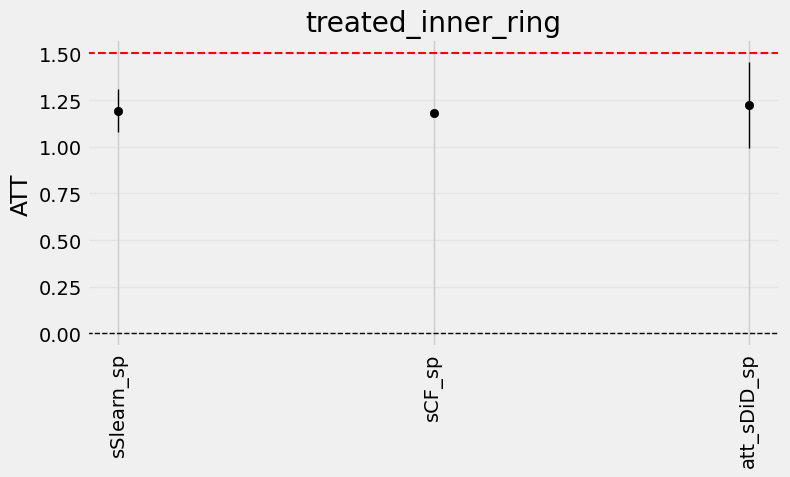

In [26]:
att_models_sp_single = {
    "sSlearn_sp": ("att_sSlearn_sp", "se_sSlearn_sp"),
    #"mLDML_sp": ("att_mLDML_sp", "se_mLDML_sp"),
    "sCF_sp": ("att_sCF_sp", "se_sCF_sp"),
    "att_sDiD_sp": ("att_sDiD_sp_pred", "se_sDiD_sp_pred"),

}

plot_att_row(
        df=df_single_effect_final,
        ring_name='treated_inner_ring',
        true_effect_col="true_effect",
        att_dict=att_models_sp_single
    )

#### Without spatial regressors

##### S learner

In [27]:
RF_s_learnerS2 = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_Sngl2, lb_slearn_Sngl2, ub_slearn_Sngl2 = RF_s_learnerS.estimate_ate(X_ns, T_S, Y, return_ci = True)
ite_slearn_Sngl2 = RF_s_learnerS2.fit_predict(X_ns, T_S, Y)
ITE_df_slearn_Sngl2 = pd.DataFrame(ite_slearn_Sngl2).rename(columns = replacing_dict_0_ring)
ITE_df_slearn_Sngl2['treated'] = T_M
ITE_df_slearn_Sngl2['ITE_real'] = gdf2['tau']
ITE_df_slearn_Sngl2['Y'] = Y
ITE_df_slearn_Sngl2

,treated_inner_ring,treated,ITE_real,Y
0,2.297340,control,0.0,0.599436
1,1.529367,control,0.0,1.897156
2,1.567956,control,0.0,0.782082
3,0.902039,control,0.0,0.078709
4,2.166771,control,0.0,0.398665
...,...,...,...,...
795,1.856641,control,0.0,0.606883
796,1.298002,control,0.0,0.227247
797,1.127433,control,0.0,-1.419136
798,1.862122,control,0.0,0.703590


In [28]:
df_single_treatment_effects_SlearnS_nsp = make_treatment_effects_df(ITE_df_slearn_Sngl2,  [ 'treated_inner_ring',
             ],'sSlearn_nsp', treated_col='treated')
df_single_effect_ns_pre1 = df_effectbase[df_effectbase['ring'] == 'treated_inner_ring'].merge(df_single_treatment_effects_SlearnS_nsp, on = 'ring', how= 'left')
df_single_effect_ns_pre1

,ring,true_effect,att_sSlearn_nsp,se_sSlearn_nsp
0,treated_inner_ring,1.5,1.580794,0.066931


##### Causal forest

In [29]:
est2S_nsp = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2S_nsp.tune(Y, T, X=X_ns, 
          #W=W
          )
est2S_nsp.fit(Y, T, X=X_ns, 
         #W=W
         )

te_pred2S_nsp = est2S_nsp.const_marginal_effect(X_ns)
ITE_CFS_nsp=pd.DataFrame(te_pred2S_nsp).rename(columns = replacing_dict_0_ring)
ITE_CFS_nsp['treated'] = T_M
df_single_treatment_effects_CF_nsp = make_treatment_effects_df(ITE_CFS_nsp,  ['treated_inner_ring',
            # 'treated_outer_ring1',
            #  'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'sCF_nsp', treated_col='treated')
df_single_effect_ns_pre2 = df_single_effect_ns_pre1.merge(df_single_treatment_effects_CF_nsp, on = 'ring', how= 'left')
df_single_effect_ns_pre2

,ring,true_effect,att_sSlearn_nsp,se_sSlearn_nsp,att_sCF_nsp,se_sCF_nsp
0,treated_inner_ring,1.5,1.580794,0.066931,1.608872,0.015365


##### DiD

In [30]:
model_cs_did_nsp_single = sm.OLS(y_l, X_l4)
results_cs_did_nsp_single = model_cs_did_nsp_single.fit()

coef_df_cs_did_nsp_single = pd.DataFrame({
    "ring": results_cs_did_nsp_single.params.index,
    "att_sDiD_nsp": results_cs_did_nsp_single.params.values,
    "se_sDiD_nsp": results_cs_did_nsp_single.bse.values
})
coef_df_cs_did_nsp_single = coef_df_cs_did_nsp_single[coef_df_cs_did_nsp_single['ring'].isin(['t'
                                                            ])].copy()

coef_df_cs_did_nsp_single['ring'] = coef_df_cs_did_nsp_single['ring'].replace(replacing_dict_odr_ring)
df_single_effect_final_nsp = df_single_effect_ns_pre2.merge(coef_df_cs_did_nsp_single, on = 'ring', how= 'left')
df_single_effect_final_nsp

,ring,true_effect,att_sSlearn_nsp,se_sSlearn_nsp,att_sCF_nsp,se_sCF_nsp,att_sDiD_nsp,se_sDiD_nsp
0,treated_inner_ring,1.5,1.580794,0.066931,1.608872,0.015365,1.393555,0.099893


##### Results visualization

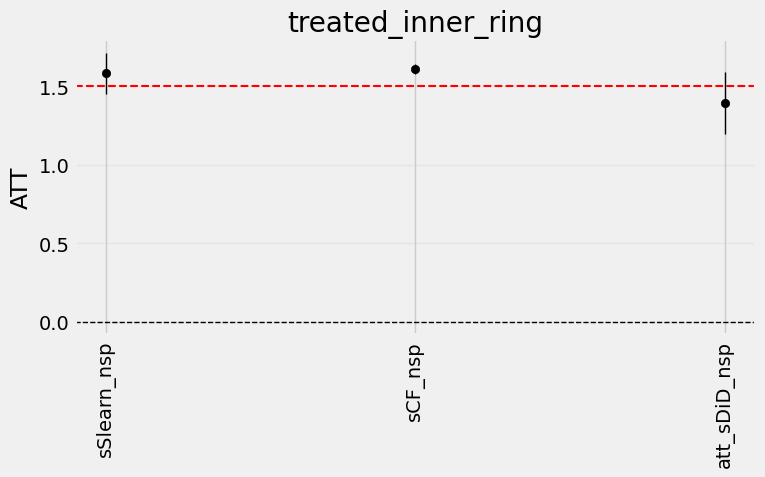

In [31]:
att_models_nsp_single = {
    "sSlearn_nsp": ("att_sSlearn_nsp", "se_sSlearn_nsp"),
    #"mLDML_sp": ("att_mLDML_sp", "se_mLDML_sp"),
    "sCF_nsp": ("att_sCF_nsp", "se_sCF_nsp"),
    "att_sDiD_nsp": ("att_sDiD_nsp", "se_sDiD_nsp"),

}

plot_att_row(
        df=df_single_effect_final_nsp,
        ring_name='treated_inner_ring',
        true_effect_col="true_effect",
        att_dict=att_models_nsp_single
    )

### Double treatment

#### S learner

In [32]:
RF_s_learner_nsp_DT = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_multT_nsp_DT, lb_slearn_multT_nsp_DT, ub_slearn_multT_nsp_DT = RF_s_learner_nsp_DT.estimate_ate(
    X_ns, T_Dbl, Y, return_ci = True)
ite_slearn_multT_nsp_DT = RF_s_learner_nsp_DT.fit_predict(X_ns, T_Dbl, Y)
ITE_df_slearn_multT_nsp_DT = pd.DataFrame(ite_slearn_multT_nsp_DT).rename(columns = {
                                            0:'treated_inner_ring', 1:'treated_outer_rings', 
                                             })
ITE_df_slearn_multT_nsp_DT['treated'] = T_M
df_dbl_treatment_effects_Slearn_nsp  = make_att_table(
    df=ITE_df_slearn_multT_nsp_DT,
    inner_ring='treated_inner_ring',
    outer_rings=[
        'treated_outer_ring1',
        'treated_outer_ring2',
        'treated_outer_ring3'
    ],
    treated_col='treated',
    suffix='Slearn_dblT'
)
df_double_vt_pre1 = df_effectbase.merge(df_dbl_treatment_effects_Slearn_nsp, on = 'ring', how= 'left')
df_double_vt_pre1

,ring,true_effect,att_Slearn_dblT,se_att_Slearn_dblT
0,treated_inner_ring,1.500000,1.760954,0.067659
1,treated_outer_ring1,0.969857,0.614554,0.075481
2,treated_outer_ring2,0.514273,0.371165,0.052607
3,treated_outer_ring3,0.112335,0.237605,0.059951


#### Causal forest

In [33]:
est2_cf_nsp_dt = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2_cf_nsp_dt.tune(Y, T_DT, X=X_ns, 
          #W=W
          )
est2_cf_nsp_dt.fit(Y, T_DT, X=X_ns, 
         #W=W
         )

te_pred2_nsp_dt = est2_cf_nsp_dt.const_marginal_effect(X_ns)
ITE_CF_nsp_DT=pd.DataFrame(te_pred2_nsp_dt ).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_rings', 

                                             })
ITE_CF_nsp_DT['treated'] = T_M


df_dbl_treatment_effects_CF  = make_att_table(
    df=ITE_CF_nsp_DT,
    inner_ring='treated_inner_ring',
    outer_rings=[
        'treated_outer_ring1',
        'treated_outer_ring2',
        'treated_outer_ring3'
    ],
    treated_col='treated',
    suffix='CF_dblT'
)
df_double_vt_pre2 = df_double_vt_pre1.merge(df_dbl_treatment_effects_CF, on = 'ring', how= 'left')
df_double_vt_pre2

,ring,true_effect,att_Slearn_dblT,se_att_Slearn_dblT,att_CF_dblT,se_att_CF_dblT
0,treated_inner_ring,1.500000,1.760954,0.067659,1.726802,0.018255
1,treated_outer_ring1,0.969857,0.614554,0.075481,0.374677,0.028456
2,treated_outer_ring2,0.514273,0.371165,0.052607,0.338810,0.027205
3,treated_outer_ring3,0.112335,0.237605,0.059951,0.308491,0.020349


#### Causal forest inverse distance

In [34]:
est2_cf_nsp_dt_id = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2_cf_nsp_dt_id.tune(Y, T_DT_id, X=X_ns, 
          #W=W
          )
est2_cf_nsp_dt_id.fit(Y, T_DT_id, X=X_ns, 
         #W=W
         )

te_pred2_nsp_dt_id = est2_cf_nsp_dt_id.const_marginal_effect(X_ns)
ITE_CF_nsp_DT_id=pd.DataFrame(te_pred2_nsp_dt_id ).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_rings', 

                                             })
ITE_CF_nsp_DT_id['treated'] = T_M

ITE_CF_nsp_DT_id['treated_outer_ring1'] = ITE_CF_nsp_DT_id['treated_outer_rings']
ITE_CF_nsp_DT_id['treated_outer_ring2'] = ITE_CF_nsp_DT_id['treated_outer_rings']/2
ITE_CF_nsp_DT_id['treated_outer_ring3'] = ITE_CF_nsp_DT_id['treated_outer_rings']/3


df_dbl_treatment_effects_CF_id = make_treatment_effects_df(ITE_CF_nsp_DT_id,  ['treated_inner_ring',
            'treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'CF_id', treated_col='treated')

# df_dbl_treatment_effects_CF_id  = make_att_table(
#     df=ITE_CF_nsp_DT_id,
#     inner_ring='treated_inner_ring',
#     outer_rings=[
#         'treated_outer_ring1',
#         'treated_outer_ring2',
#         'treated_outer_ring3'
#     ],
#     treated_col='treated',
#     suffix='CF_dblT_id'
# )
df_double_vt_final = df_double_vt_pre2.merge(df_dbl_treatment_effects_CF_id, on = 'ring', how= 'left')
df_double_vt_final

,ring,true_effect,att_Slearn_dblT,se_att_Slearn_dblT,att_CF_dblT,se_att_CF_dblT,att_CF_id,se_CF_id
0,treated_inner_ring,1.500000,1.760954,0.067659,1.726802,0.018255,1.754038,0.023024
1,treated_outer_ring1,0.969857,0.614554,0.075481,0.374677,0.028456,1.046520,0.030959
2,treated_outer_ring2,0.514273,0.371165,0.052607,0.338810,0.027205,0.506364,0.014888
3,treated_outer_ring3,0.112335,0.237605,0.059951,0.308491,0.020349,0.334756,0.007817


#### Results visualization

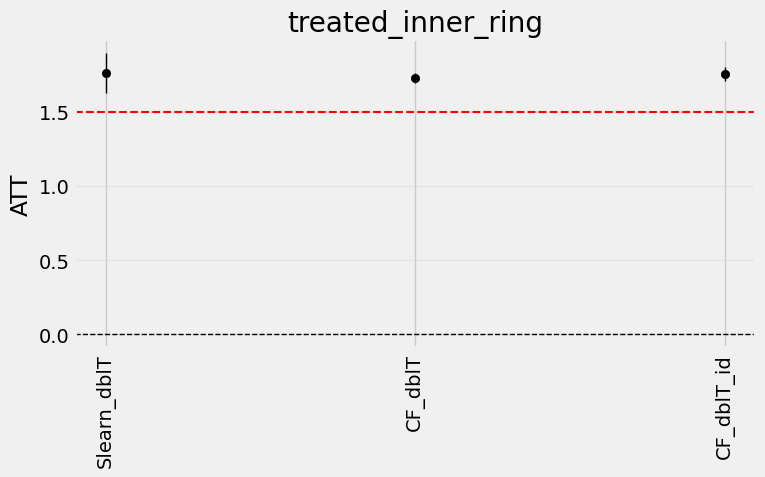

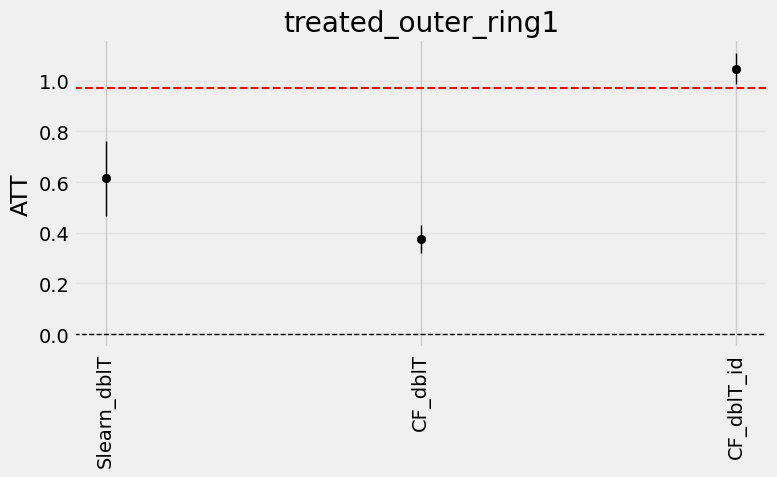

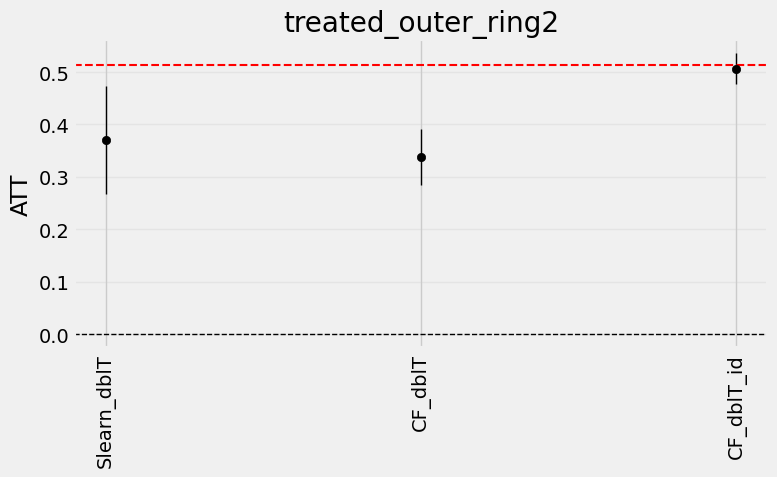

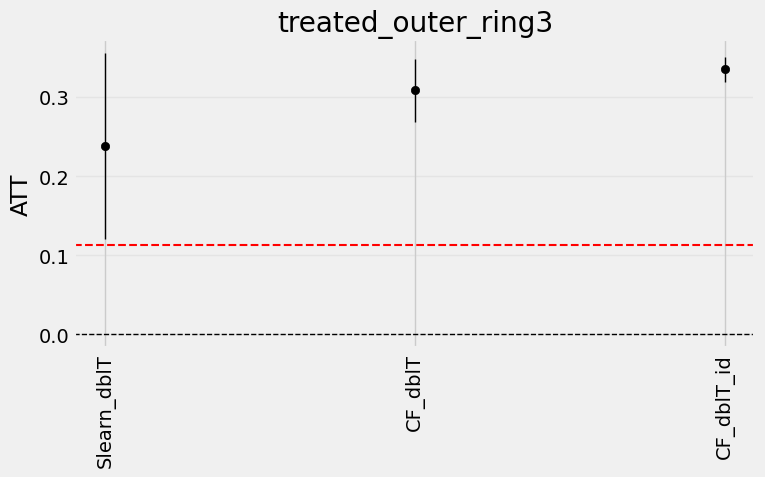

In [35]:
att_models_nspreg_id = {
    "Slearn_dblT": ("att_Slearn_dblT", "se_att_Slearn_dblT"),
    "CF_dblT": ("att_CF_dblT", "se_att_CF_dblT"),
    "CF_dblT_id": ("att_CF_id", "se_CF_id")
}
for ring in df_double_vt_final['ring'].unique().tolist():
    plot_att_row(
        df=df_double_vt_final,
        ring_name=ring,
        true_effect_col="true_effect",
        att_dict=att_models_nspreg_id
    )